<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javier Pinochet
- Nombre de alumno 2: Daniel Muñoz


### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/danmc899/MDS7202)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/diabetes_data.csv')
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [2]:
!pip install xgboost

In [3]:
!pip install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2


In [4]:
# Inserte su código aquí
from ydata_profiling import ProfileReport

# Inserte su código aquí
profile = ProfileReport(df, title="Perfil Exploratorio de Diabetes", explorative=True)
profile.to_file("profiling_report.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [00:06<00:00,  2.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Las alertas generadas son
1. Dataset has 3971 (5.6%) duplicate rows
2. DiffWalk is highly overall correlated with GenHlth  
3. GenHlth is highly overall correlated with DiffWalk  
4. CholCheck is highly imbalanced (83.3%)
5. HvyAlcoholConsump is highly imbalanced (74.5%)
6. Stroke is highly imbalanced (66.4%)
7. Diabetes is uniformly distributed
8. MentHlth has 48091 (68.0%) zeros
9. PhysHlth has 39915 (56.5%) zeros

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Clase IQR
class IQR(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, lam=1.5):
        self.columns = columns
        self.lam = lam

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.columns is None:
            self.columns_ = X.select_dtypes(include=[np.number]).columns.tolist()
        else:
            self.columns_ = list(self.columns)

        # Calcular Q1, Q3 y IQR utilizando train
        q1 = X[self.columns_].quantile(0.25)
        q3 = X[self.columns_].quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - self.lam * iqr).to_dict()
        self.upper_ = (q3 + self.lam * iqr).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns_:
            if col in X.columns:
                # Reemplazar outliers con NaN
                mask = (X[col] < self.lower_[col]) | (X[col] > self.upper_[col])
                X.loc[mask, col] = np.nan
        return X

    def set_output(self,transform='default'):
    #No modificar esta función
        return self

# 1. Separar features y target
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# 2. Eliminar duplicados ANTES de dividir train/test
df_clean = df.drop_duplicates()
X = df_clean.drop('Diabetes', axis=1)
y = df_clean['Diabetes']

# 3. Eliminar DiffWalk por alta correlación
X = X.drop('DiffWalk', axis=1)

# 4. División train/test (1/3 para test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y
)

# 5. Crear el ColumnTransformer (solo passthrough, sin imputación)
preprocessor = ColumnTransformer(
    transformers=[
        ('passthrough', 'passthrough', X_train.columns.tolist())
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')

# 6. Crear el pipeline completo
pipeline = Pipeline(steps=[
    ('iqr_outliers', IQR(columns=['BMI', 'MentHlth', 'PhysHlth'], lam=1.5)),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# 7. Entrenar el modelo
pipeline.fit(X_train, y_train)

# 8. Hacer predicciones
y_pred = pipeline.predict(X_test)

# 9. Evaluar el modelo
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred))

# Información adicional
print("\n" + "=" * 60)
print("INFORMACIÓN DEL MODELO")
print("=" * 60)
print(f"Tamaño conjunto entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto prueba: {X_test.shape}")
print(f"Features utilizadas: {X_train.shape[1]}")
print(f"Duplicados eliminados: {len(df) - len(df_clean)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [23:56:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.74      0.67      0.70     10207
         1.0       0.72      0.79      0.75     11133

    accuracy                           0.73     21340
   macro avg       0.73      0.73      0.73     21340
weighted avg       0.73      0.73      0.73     21340


INFORMACIÓN DEL MODELO
Tamaño conjunto entrenamiento: (42680, 16)
Tamaño conjunto prueba: (21340, 16)
Features utilizadas: 16
Duplicados eliminados: 6672


1. ¿Es acaso un buen predictor de diabetes? Sí, lo es, ya que en el 73% de los casos acierta correctamente.

2. ¿Qué buscan explicar las métricas utilizadas? El 79% de los casos que predice como positivos, efectivamente lo son. Con respecto a precision, el 72% de los casos que son positivos, el modelo logra predecirlos correctamente. El F1-score, que es una métrica que combina precision y recall, es de 0.75, lo que indica un buen equilibrio entre ambas métricas, por lo que se puede generalizar para el estudio de ambos casos (si o si acertar con recall o no querer equivocarse con precision).

3. ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features? No, estas métricas no aseguran que su modelo haya hecho una buena elección de las features. Este classification report mide el rendimiento predictivo del modelo (el "qué": qué tan bien acierta), pero no explica su funcionamiento interno (el "cómo" o el "porqué": qué características usó y por qué fueron importantes).

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

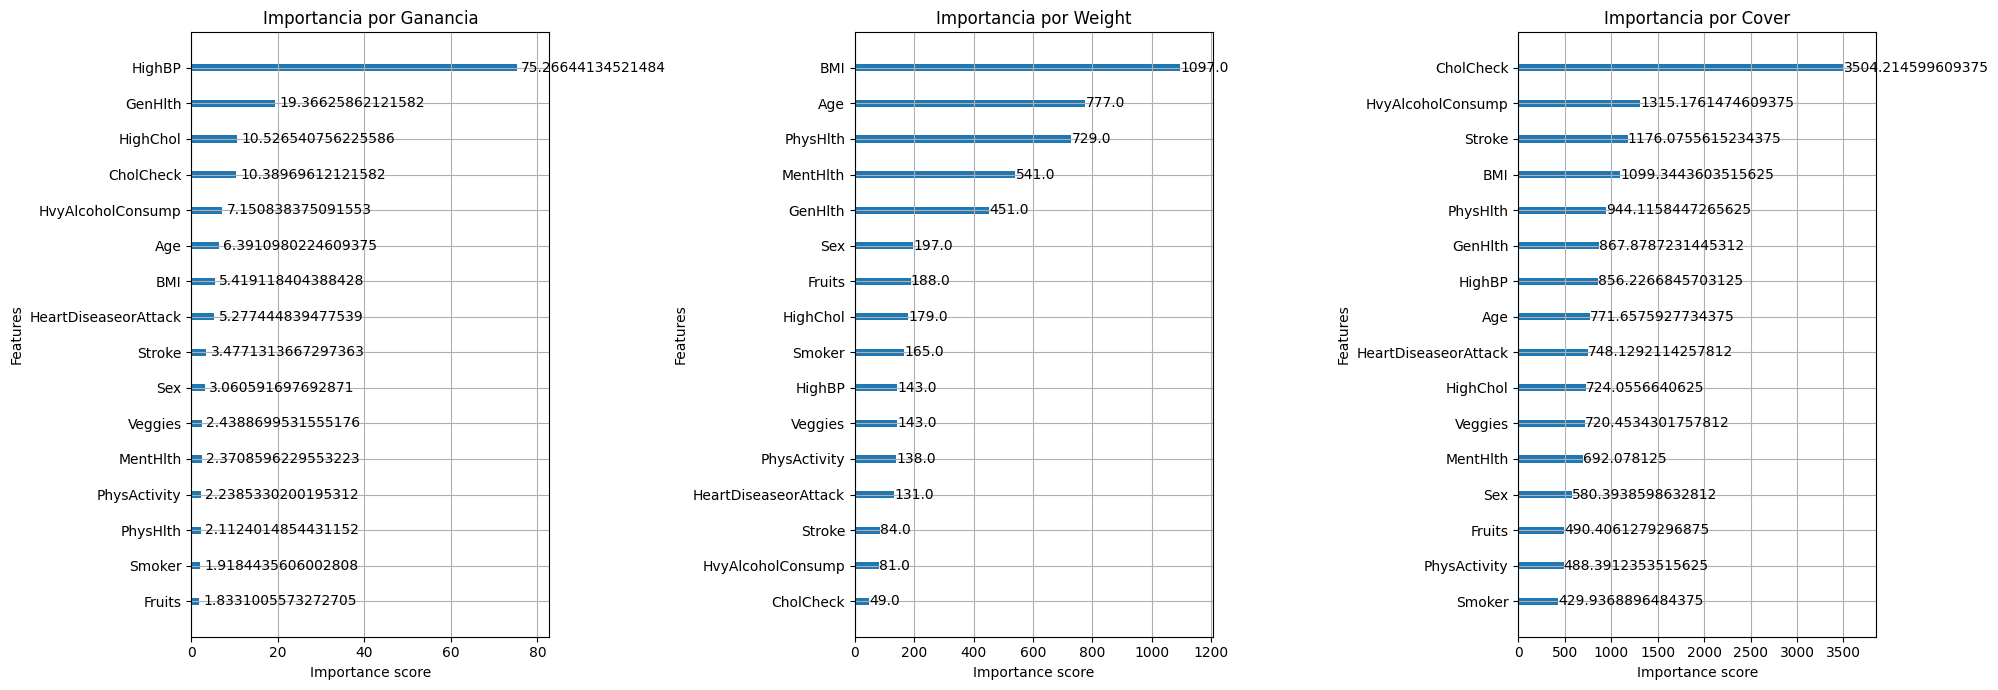

In [6]:
# Inserte su código aquí
from xgboost import plot_importance

# Se accede al paso clasificador de XGBoost
xgb_model = pipeline.named_steps['classifier']

# Se crean los gráficos de importancia de feature para cada métrica
fig, ax = plt.subplots(1, 3, figsize=(20, 7))

# Gráfico para ganancia
plot_importance(xgb_model, importance_type='gain', ax=ax[0], title='Importancia por Ganancia')

# Gráfico para weight
plot_importance(xgb_model, importance_type='weight', ax=ax[1], title='Importancia por Weight')

# Gráfico para cover
plot_importance(xgb_model, importance_type='cover', ax=ax[2], title='Importancia por Cover')

# Ajustar diseño
plt.tight_layout()
plt.show()


Los resultados para cada método no son iguales, dado que tienen distintos criterios para medir la información.

1. La importancia por *gain* mide la contribución, en promedio, en la precision que aporta una variable cada vez que se usa en una división. La mejor aquí es HighBP, que significa la presión arterial alta.
2. La importancia por *weight* mide el número de veces que una característica es utilizada para dividir el árbol. Aquí la mejor es BMI, que es el índice de masa corporal.
3. La importancia por *cover* mide la cobertura promedio de las predicciones que realiza un modelo con respecto a una característica. En este caso, la mejor es también CholCheck, que significa la revisión del colesterol.

Entonces, se dice que los tres resultados se complementan entre sí.

No es suficiente para la interpretabilidad. Si bien nos da una idea de qué variables son más importantes, no nos dice cómo estas variables afectan las predicciones del modelo. Además, este método no proporciona información sobre las interacciones entre variables ni sobre la dirección del efecto (positivo o negativo) que cada variable tiene en la predicción. También, sufre de sesgo hacia variables continuas o de alta cardinalidad, dado que estas variables tienen más oportunidades de ser seleccionadas para divisiones en los árboles.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [7]:
# Inserte su código aquí
from sklearn.inspection import permutation_importance
import plotly.express as px

# hacemos la permutación de características
r = permutation_importance(pipeline, X_test, y_test, n_repeats=30, scoring='accuracy', random_state=42, n_jobs=-1)

# obtenemos los nombres de las características
feature_names = pipeline.named_steps['classifier'].get_booster().feature_names

# Crear el dataframe para visualizar los resultados
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance_means': r.importances_mean,
    'importance_std': r.importances_std,
}).sort_values(by='importance_means', ascending=True)

# Visualizamos los resultados
fig = px.bar(df_importance, x='importance_means', y='feature', orientation='h',
             title='Importancia de las características por Permutation Importance',
             labels={'importance_means': 'Disminución media en el rendimiento'},
             error_x='importance_std'
             )

fig.update_layout(
    yaxis_title='Características',
    xaxis_title='Importancia de la característica'
)

fig.show()

1. ¿Cómo mide la importancia de las features su propuesta? El método de importancia por permutación mide cuánto se degrada el rendimiento del modelo cuando la información de esa característica es destruida o aleatorizada. Para lograrlo, se calcula una métrica de rendimiento, tal como _accuracy_. Luego, para una sola columna, se permutan aleatoriamente sus valores y se vuelve a calcular la métrica de rendimiento. La importancia de la característica se define como la diferencia entre la métrica original y la métrica obtenida después de la permutación. Si la métrica disminuye significativamente, indica que la característica es importante para el modelo.

2. ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? Las cinco características con mayor impacto en la salida del modelo son:
- GenHlth (Salud general): La percepción del propio paciente sobre su estado de salud general.
- BMI (Índice de masa corporal): La relación entre peso y altura.
- Age (Edad): La edad del paciente.
- HighBP (Presión arterial alta): Indica si el paciente tiene hipertensión.
- HighChol (Colesterol alto): Indica si el paciente tiene niveles elevados de colesterol.

Estas características tienen sentido desde una perspectiva médica y como síntomas preventivos de la diabetes.

3. ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? Las conclusiones cambian en el sentido de que el método de permutación proporciona una evaluación más robusta y menos sesgada de la importancia de las características. Mientras que *gain* seleccionó a HighBP como la característica más importante, *weight* a BMI y *cover* a CholCheck, la permutación identificó a GenHlth como la más relevante. Esto sugiere que GenHlth tiene un impacto significativo en las predicciones del modelo, lo que no fue capturado por los métodos basados en árboles. La degradación de CholCheck en la importancia, lo que da a entender que, aunque pueda cubrir a muchas personas, romper su conexión con el objetivo de detectar diabetes no perjudica tanto al rendimiento.

4. Ventajas y desventajas del método implementado.

Ventajas:
- *Alta Fiabilidad y Relevancia:* Mide directamente el impacto en el rendimiento del modelo sobre datos no vistos. Es la definición más pragmática de "importancia": una variable es importante si el modelo funciona peor sin ella.
- *Independiente del Modelo (Model-Agnostic):* A diferencia de *gain* o *weight* que son específicos de los modelos de árboles, la importancia por permutación se puede usar con cualquier tipo de modelo (redes neuronales, SVM, regresión logística, etc.).
- *Captura de Interacciones:* Al permutar una variable, se rompen no solo sus efectos directos, sino también sus interacciones con todas las demás variables, lo que proporciona una evaluación más global de su valor.

Desventajas:
- *Costo Computacional:* Es mucho más lento que los métodos internos, ya que requiere hacer múltiples predicciones (n_repeats) para cada característica del dataset. En datasets muy anchos (muchas columnas), puede ser prohibitivo.
- *Problema con Variables Correlacionadas:* Si dos variables están fuertemente correlacionadas (por ejemplo, DiffWalk y PhysHlth), permutar una de ellas podría no degradar mucho el rendimiento, porque el modelo obtiene la misma información de la otra variable. Esto puede llevar a subestimar la importancia de ambas características correlacionadas.
- *Dependencia de un Conjunto de Datos de Prueba:* El método requiere un conjunto de test para ser evaluado. Si se aplica sobre los mismos datos de entrenamiento, los resultados pueden ser demasiado optimistas y poco fiables.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [8]:
!pip install shap

In [9]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import shap

In [10]:
# Inserte código para calcular shapley values aquí

# Seleccionamos el modelo xgboost del pipeline
pre_fitted = pipeline.named_steps['preprocessor']
model_shap = pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(model_shap)

# Transformar X_test usando el preprocesador
X_test_transformed = pre_fitted.transform(X_test)
feature_names = pre_fitted.get_feature_names_out()

# Convertir a DataFrame
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# Calcular los shap_values
shap_values = explainer.shap_values(X_test_transformed)

# Inicializar la visualización de Shap
shap.initjs()

# Análisis para un paciente
print("SHAP para un paciente específico")
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    X_test.iloc[0,:]
)

SHAP para un paciente específico


2. ¿Qué representa cada número en su resultado?

- El base value es el punto de partida y representa la predicción promedio del modelo para todo el conjunto de datos.
- f(x) = 0.78 es el resultado final del modelo para el paciente específico.
- Las flechas rojas y azules representa el impacto de una característica individual en la predicción. La longitud de la flecha indica la magnitud de su impacto para obtener el resultado final.

3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor?

Sí, es posible, ya que cada valor SHAP explica una predicción de manera aditiva.
- Las flechas rojas son los SHAP values positivos, que empujan la predicción hacia arriba = 1, indicando la probabilidad de que el paciente tenga diabetes (Tener un BMI relativamente bajo, actividad física y no tener un ataque al corazón).
- Las flechas azules son los SHAP values negativos, que empujan la predicción hacia abajo, indicando que la característica disminuye la probabilidad de que el paciente tenga diabetes (ser fumador, ser del sexo = 1, tener una edad de 9, tener colesterol y presión alta).

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

--- Análisis para el paciente en la instancia 1 ---


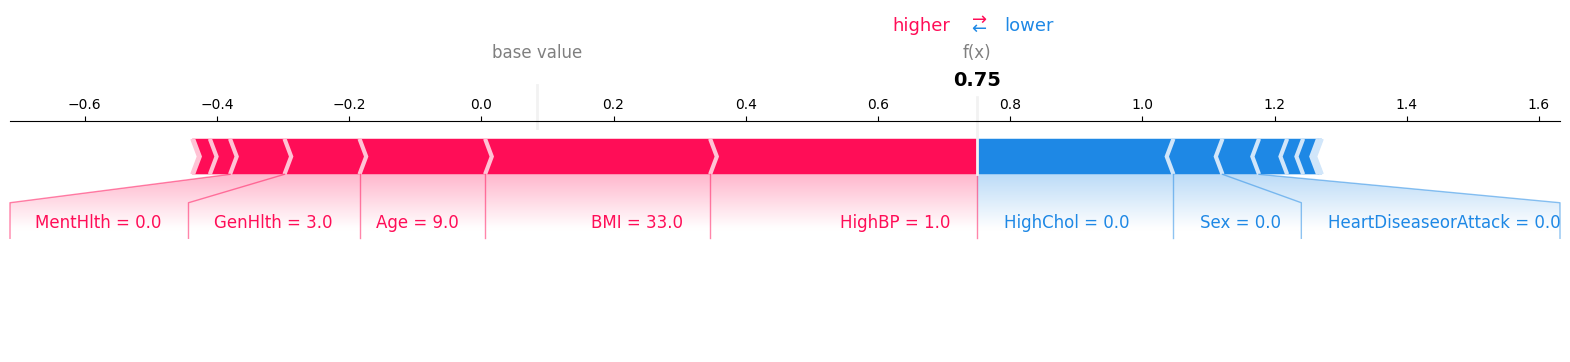

None


--- Análisis para el paciente en la instancia 9 ---


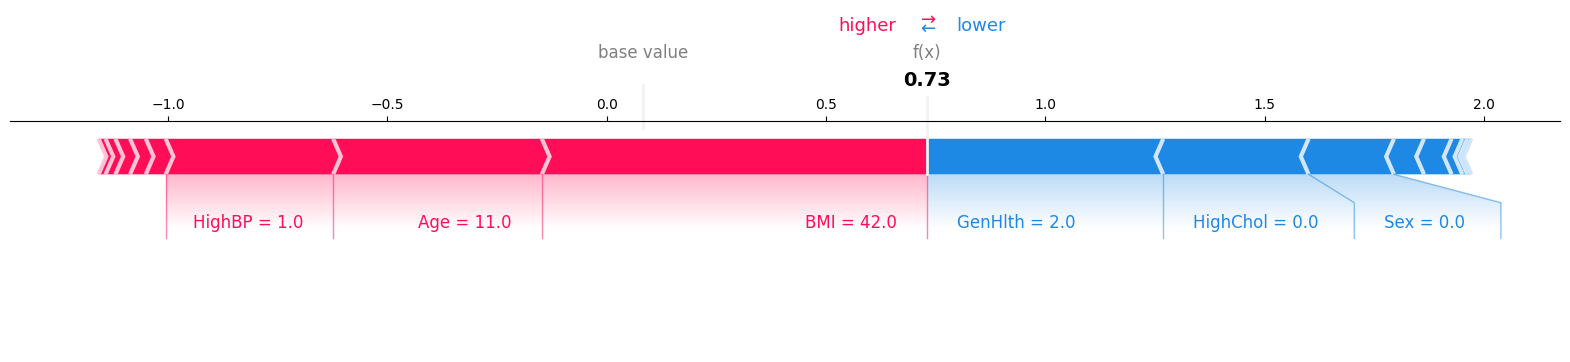

None


--- Análisis para el paciente en la instancia 150 ---


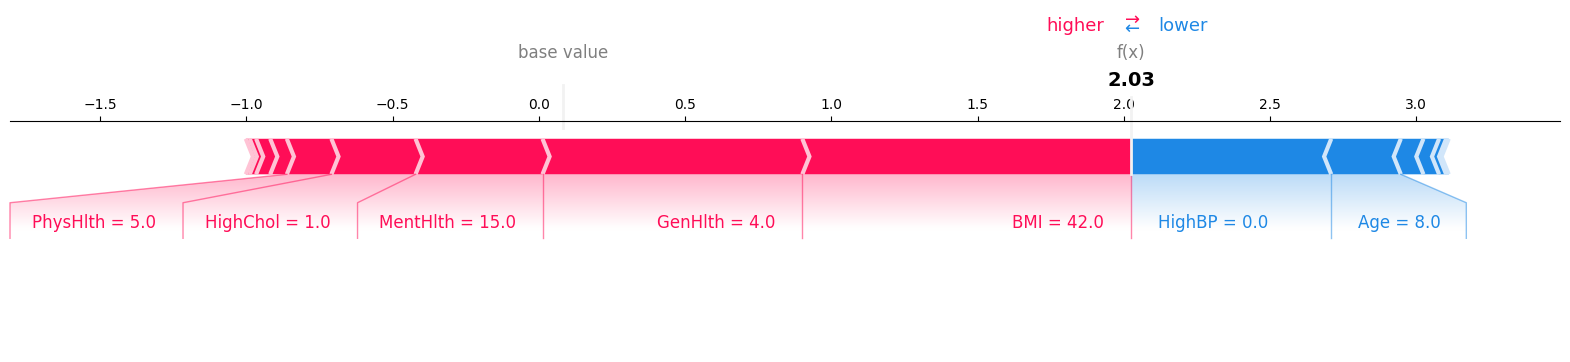

None

In [11]:
# Inserte código para generar gráficos de aporte local aquí
from IPython.display import display

print("--- Análisis para el paciente en la instancia 1 ---")
# Usamos .iloc[1] para acceder al segundo paciente (índice 1)
display(shap.force_plot(
    explainer.expected_value,
    shap_values[1,:],
    X_test.iloc[1,:],
    matplotlib=True
))

print("\n--- Análisis para el paciente en la instancia 9 ---")
# Usamos .iloc[9] para acceder al décimo paciente (índice 9)
display(shap.force_plot(
    explainer.expected_value,
    shap_values[9,:],
    X_test.iloc[9,:],
    matplotlib=True
))

print("\n--- Análisis para el paciente en la instancia 150 ---")
# Usamos .iloc[150] para acceder al paciente en el índice 150
display(shap.force_plot(
    explainer.expected_value,
    shap_values[150,:],
    X_test.iloc[150,:],
    matplotlib=True
))

1. ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes?

Cada instancia tiene un conjunto único de características que afectan su probabilidad de tener diabetes. Por ejemplo:
- Instancia 1: Las principales variables que empujan la predicción son la presión arterial alta, el índice de masa corporal elevado y su pequeña edad. Las variables que disminuyen la probabilidad son tener no tener un colesterol alto, ser del sexo = 0, no tener un ataque al corazón ni haber tenido un derrame cerebral (stroke).
- Instancia 9: Afectan positivamente tener una presión arterial alta y un BMI alto. Disminuyen la probabilidad tener una percepción de salud alta, no tener el colesterol alto, ser del sexo = 0
- Instancia 150 (riesgo altísimo): Afectan positivamente tener un BMI alto, una mala percepción de salud, una mala salud mental y colesterol alto. Disminuyen la probabilidad no tener una presión arterial alta y ser de una edad baja.

2. ¿Existe algún patrón común entre las instancias analizadas?
Sí. Existen variables que consistentemente afectan la probabilidad de tener diabetes, tales como tener un BMI alto, Tener una mala percepción de salud general (mental o física), tener un colesterol alto y tener una presión arterial alta. Las variables que disminuyen la probabilidad son el complemento de las anteriores.

3. ¿Es posible generalizar estas conclusiones a todo el dataset?
Solamente en las variables que se repiten en las tres instancias. Sin embargo, factores más específicos, como la edad, el sexo, el historial de ataques cardíacos o derrames cerecrables pueden variar significativamente entre individuos. Este estudio corresponde a individuos específicos. La importancia de una variable puede cambiar drásticamente dependiendo del contexto para las otras instancias.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

--- Gráfico de resumen del impacto de las features a nivel global ---


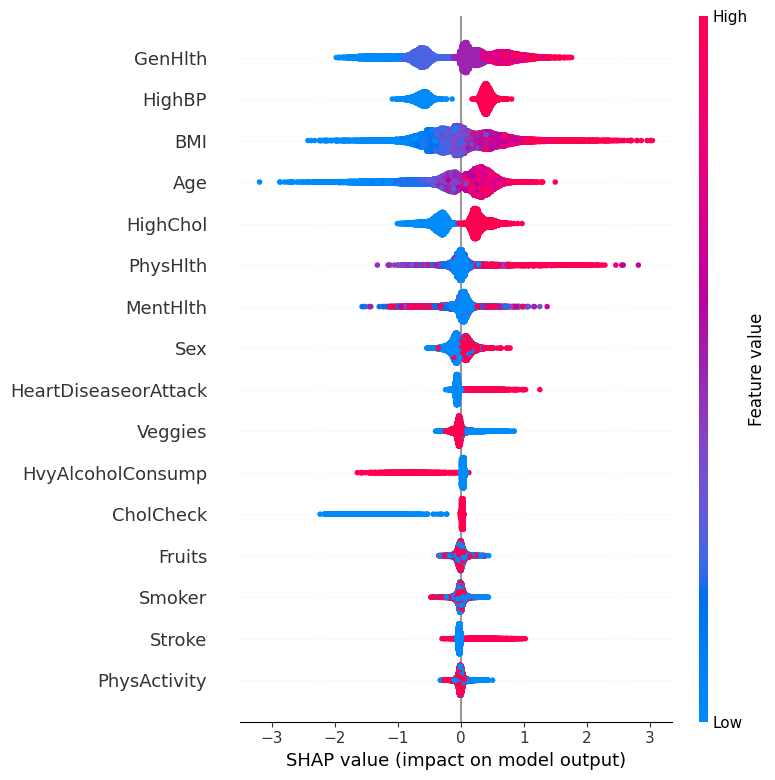

In [12]:
# Inserte código para generar gráficos de aporte global aquí
# Inserte código para generar gráficos de aporte global aquí
print("--- Gráfico de resumen del impacto de las features a nivel global ---")
shap.summary_plot(
    shap_values,          # Los SHAP values calculados para todo el conjunto de prueba
    X_test_transformed,   # Los datos de prueba transformados para asignar colores
    plot_type="dot"       # El tipo de gráfico
)

**¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?**

Primeramente, aquí se visualiza el comportamiento del impacto de las features sobre todas las personas, en lugar de analizar solo una persona.

Hay features como la salud general, la presión alta, el BMI, la edad y el colesterol alto que cobran más importancia, porque son las que muestran dispersiones más evidentes. A diferencia de cómo se veía a nivel de instancias, donde había pacientes donde la salud general, colesterol alto o la edad podían tener un impacto positivo o negativo sobre su diagnóstico. Con este gráfico queda más claro hacia donde tienen más impacto las variables a nivel general.

Hay otras features para las cuales encontrar hacia donde impactan más se vuelve más complicado, ya que no existe la misma dispersión que para variables mencionadas, estas son por ejemplo, salud física, salud mental, actividad física y fumador; para estas, es difícil notar una tendencia sobre el impacto que puedan tener.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

Top 5 features más importantes globalmente:
Index(['GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol'], dtype='object')


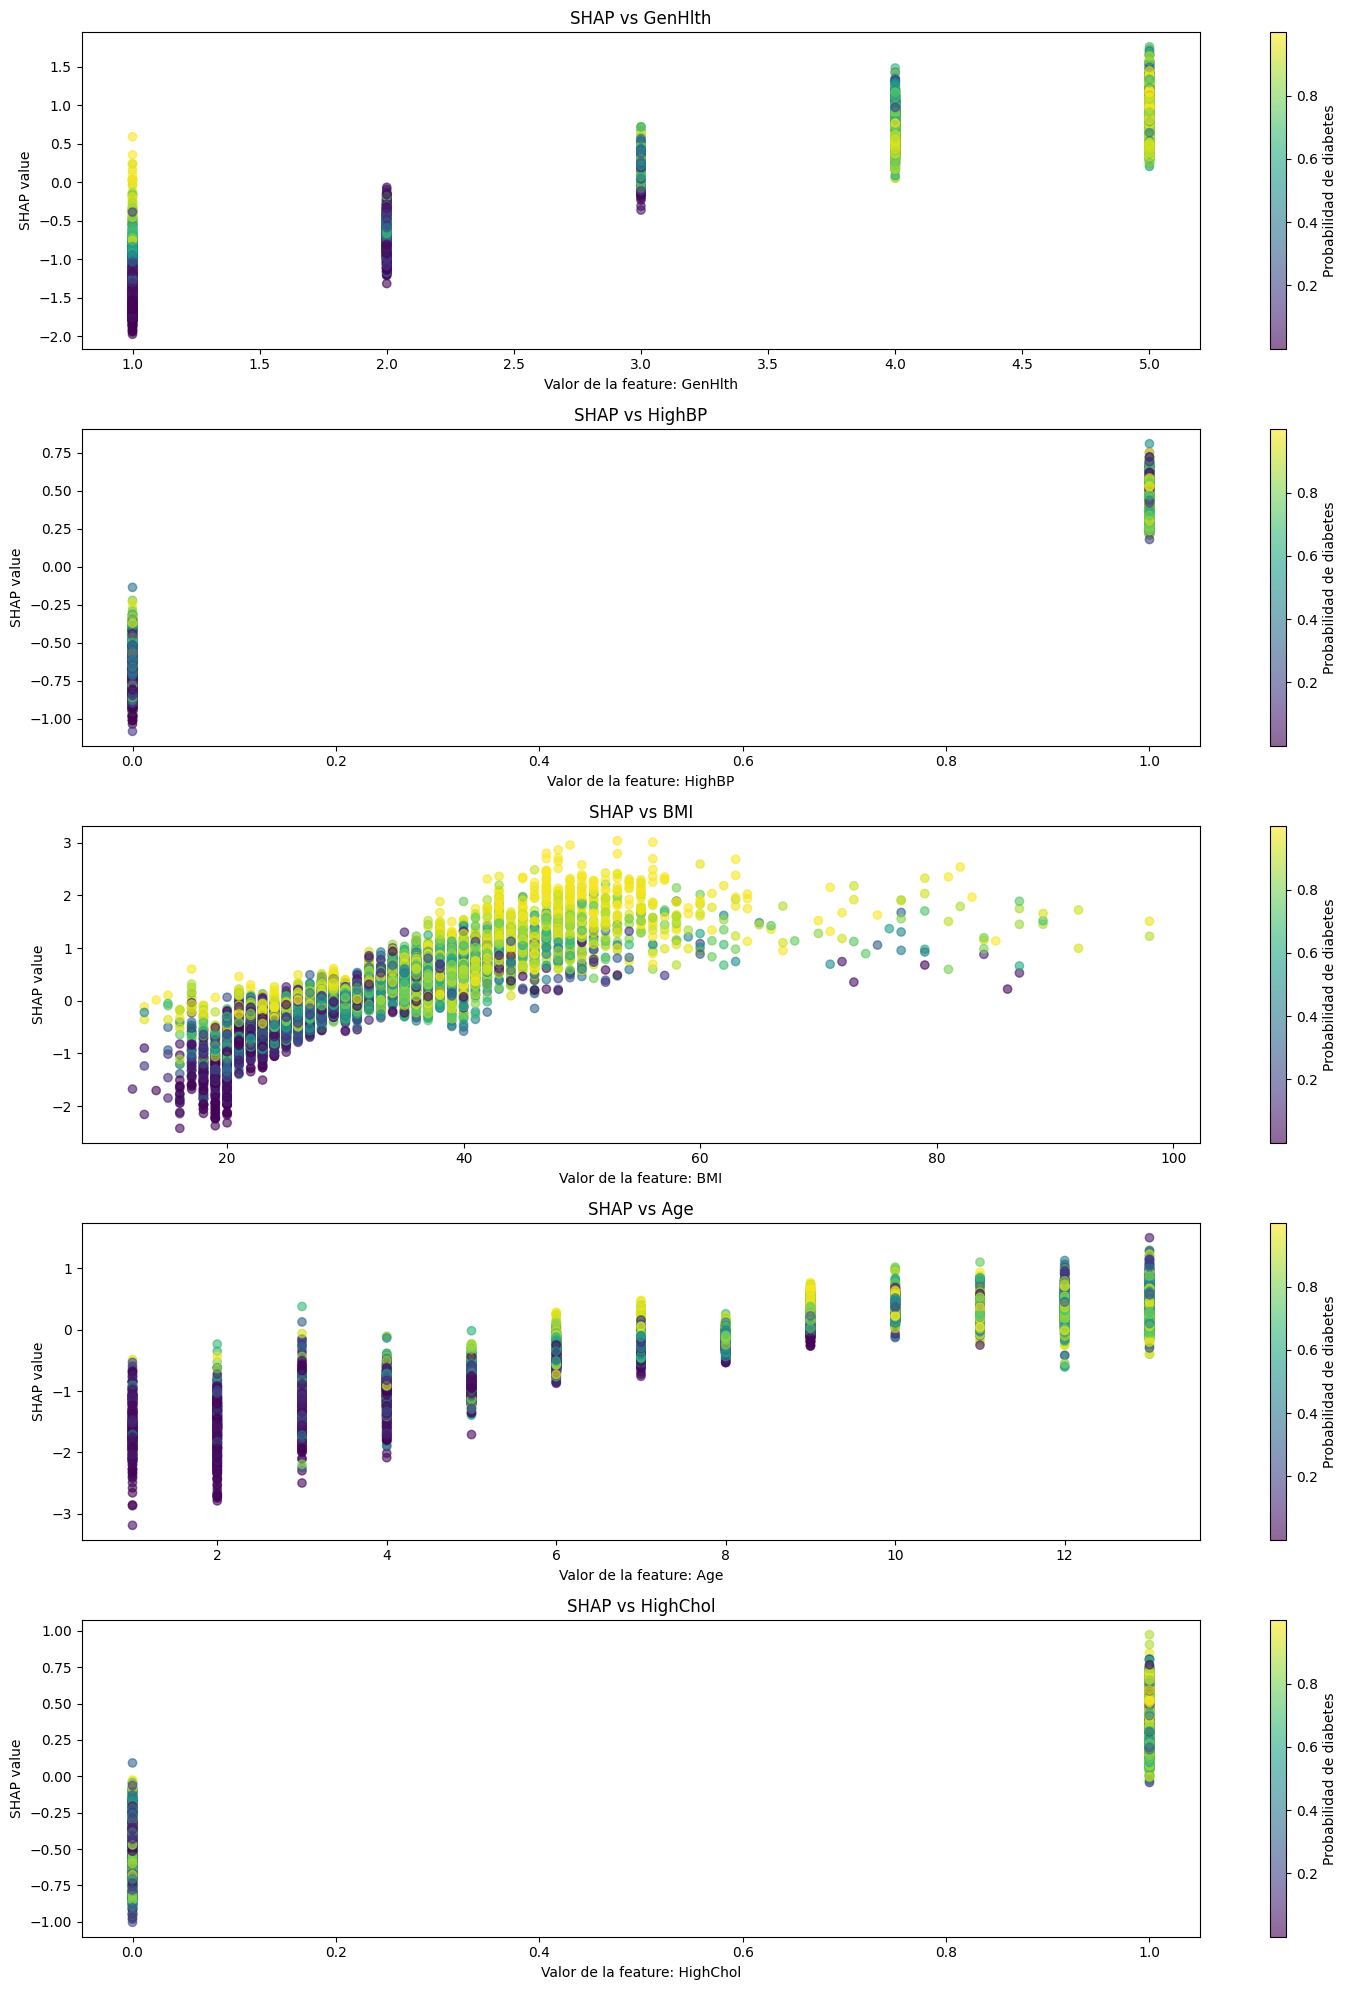

In [13]:
# Inserte código para generar gráficos de feature vs shap value aquí
# Inserte código para generar gráficos de feature vs shap value aquí
import numpy as np
import matplotlib.pyplot as plt

# Calcular importancia global (media del valor absoluto de SHAP por feature)
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Obtener índices de las 5 features más importantes
top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top5_features = X_test_transformed.columns[top5_idx]

print("Top 5 features más importantes globalmente:")
print(top5_features)

# Calcular probabilidades de tener diabetes
y_proba = model_shap.predict_proba(X_test_transformed)[:, 1]  # Clase positiva

# Graficar
plt.figure(figsize=(15, 20))
for i, feature in enumerate(top5_features):
    plt.subplot(5, 1, i + 1)
    plt.scatter(
        X_test_transformed[feature],
        shap_values[:, top5_idx[i]],
        c=y_proba,
        alpha=0.6
    )
    plt.colorbar(label='Probabilidad de diabetes')
    plt.xlabel(f'Valor de la feature: {feature}')
    plt.ylabel('SHAP value')
    plt.title(f'SHAP vs {feature}')

plt.tight_layout()
plt.show()

**¿Qué puede concluir de sus resultados?**

Para la variable de salud general, se observa que a medida que crece esta variable y los valores shap se tornan positivos, la probabilidad de diagnosticar diabetes se acerca a 1.
Para la presión alta, también a medida que aumenta esta y los valores shap, las probabilidades tienden a 1.
Para la edad, al igual que los casos anteriores, al aumentar esta y los valores shap las probabilidades se acercan a 1.

Para el BMI, al ser una variable continua, es diferente a los demás gráficos, pero la tendencia parece ser la misma, a medida que crece el BMI, o crecen los valores shap, las probabilidades de diabetes también aumentan; aunque en este caso hay que notar que hay una acumulación de valores shap positivos en un BMI entre el 40 y 60; a más de 60 los valores shap se acercan al 0.

Y por último, para el colesterol alto, es un poco más dificil de observar porque si bien a medida que aumenta el colesterol, también aumentan los valores shap, se pueden observar que las probabilidades tampoco están del todo separadas; pero si miramos a nivel general se observan mayores probabilidades en valores shap y colesterol altos.

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

In [14]:
# pip install -U scikit-learn

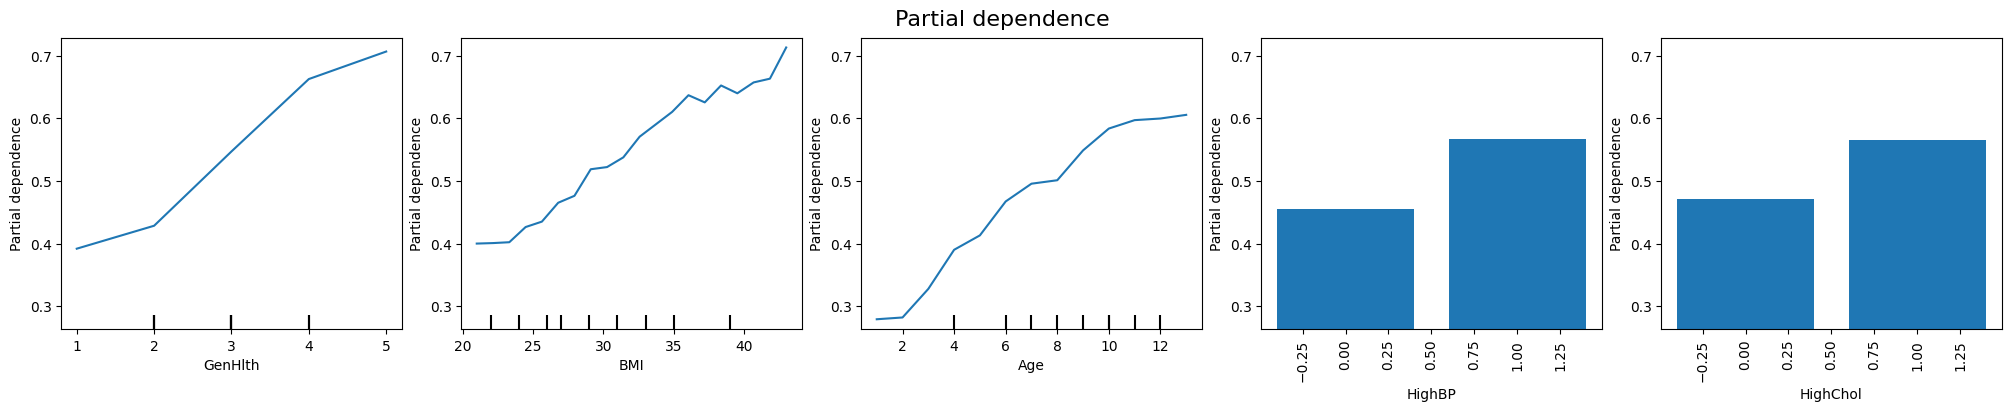

In [21]:
# Inserte código para generar gráficos PDP aquí
common_params = {
    "subsample": 1000,
    "n_jobs": 2,
    "grid_resolution": 20,
    "random_state": 42,
}

features_info = {
    # features
    "features": ["GenHlth", "BMI", "Age", "HighBP", "HighChol"],
    # type of partial dependence plot
    "kind": "average",
    # information regarding categorical features
    "categorical_features": ["HighBP", "HighChol"]
}
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

_, ax = plt.subplots(ncols=5, nrows=1, figsize=(20, 4), constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(
    pipeline,
    X_train,
    **features_info,
    ax=ax,
    **common_params,
)
_ = display.figure_.suptitle(
    "Partial dependence ",
    fontsize=16,
)

**¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?**

A mayores valores de salud general, la probabilidad de diagnosticar diabetes pasa de 0.4 a 0.7 en su valor máximo (5). Para el BMI pasa desde 0.4 a 0.7 hacia valores mayores de 40. Para la edad, pada de 0.3 a 0.6 en sus valores máximos (12). Y para colesterol alto y presión alta, el contar con estas características registran unas probabilidades de alrededor de 0.55 para diagnósticos positivos.

Estas conclusiones son solo generalizables entre estas 5 features ya que son las más importantes según el aporte global, y las que aportan más a predecir un diagnóstico; sin embargo, no lo son para todas las features del dataframe, ya que como se vio antes algunas features, no presentan dispersiones claras en sus valores shap; por tanto sus probabilidades podrían no tener esta monotonía de las features importantes.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [16]:
# !pip install alibi

In [17]:
from alibi.explainers import AnchorTabular

In [22]:
import numpy as np
import pandas as pd
from alibi.explainers import AnchorTabular



#
assert len(feature_names) == X_train.shape[1], "feature_names length != n_columns of X_train"

#
def predict_fn_from_array(x):
    """
    x: numpy array of shape (n_samples, n_features) OR (n_features,) for a single instance.
    We convert to 2D and cast to DataFrame with correct columns before calling pipeline.predict.
    """
    arr = np.asarray(x)
    #
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    #
    if arr.shape[1] != len(feature_names):
        raise ValueError(f"predict_fn received array with {arr.shape[1]} cols but expected {len(feature_names)}")
    #
    df = pd.DataFrame(arr, columns=feature_names)
    #
    df = df.astype(X_train.dtypes.to_dict(), copy=False)
    #
    return pipeline.predict(df)

#
sample_array = X_train.iloc[:3].values
#

#
explainer = AnchorTabular(predict_fn_from_array, feature_names=feature_names, seed=1)

#
X_train_vals = X_train.values  #
explainer.fit(X_train_vals, y_train.values)

#
idx = 1000
obs_df = X_test.iloc[idx:idx+1]            #
obs = obs_df.values                        #
#

#
explanation = explainer.explain(obs, threshold=0.95)

print('Prediction: ', pipeline.predict(obs_df)[0])
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision (explainer): %.2f' % explanation.precision)
print('Coverage (explainer): %.2f' % explanation.coverage)

Prediction:  0
Anchor: HighBP <= 0.00 AND PhysHlth <= 0.00 AND HeartDiseaseorAttack <= 0.00 AND PhysActivity > 0.00 AND Stroke <= 0.00 AND BMI > 13.00
Precision (explainer): 0.74
Coverage (explainer): 0.18


In [23]:
#
idx = 3001
obs_df = X_test.iloc[idx:idx+1]            #
obs = obs_df.values                        #
#

#
explanation = explainer.explain(obs, threshold=0.95)

print('Prediction: ', pipeline.predict(obs_df)[0])
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision (explainer): %.2f' % explanation.precision)
print('Coverage (explainer): %.2f' % explanation.coverage)

Prediction:  1
Anchor: GenHlth > 1.00 AND HighBP > 0.00 AND HighChol > 0.00 AND MentHlth <= 0.00 AND Age > 1.00 AND BMI > 19.00 AND Fruits <= 0.00 AND CholCheck > 0.00
Precision (explainer): 0.92
Coverage (explainer): 0.10


In [24]:
#
idx = 5751
obs_df = X_test.iloc[idx:idx+1]            #
obs = obs_df.values                        #
#

#
explanation = explainer.explain(obs, threshold=0.95)

print('Prediction: ', pipeline.predict(obs_df)[0])
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print('Precision (explainer): %.2f' % explanation.precision)
print('Coverage (explainer): %.2f' % explanation.coverage)

Prediction:  1
Anchor: HeartDiseaseorAttack > 0.00 AND HighBP > 0.00 AND Veggies <= 0.00 AND PhysHlth > 0.00
Precision (explainer): 0.98
Coverage (explainer): 0.02


**¿Tienen sentido sus reglas propuestas para las observaciones?**

Primeramente, para la instancia 1000, donde predijo 0, el modelo usó reglas con algunas features  de gran impacto como la presión alta o el BMI, pero otras de bajo impacto como la salud física o si tuvo un paro cardiaco (Stroke); solo tiene sentido en el caso de la presion alta, que es donde siguió una regla que debía ser menor o igual a 0, es decir no tener presión alta. Además si bien las reglas tienen relativamente alta precisión, tiene baja cobertura en el dataset total.

Para la instancia 3001, donde predijo 1, la mayoría de las reglas tienen sentido, ya que se usaron features importantes (salud general, presión alta, colesterol alto, edad) y en rangos adecuados, es decir los situados a los valores máximos, solo puede ser rara la elección de Fruits como feature, ya que no tiene un impacto claro según se vio antes. Además estas reglas tienen una muy alta precisión pero una baja cobertura, tal vez porque las reglas siguen casos particulares.

Para la instancia 5751, donde se predijo 1, hay dos reglas que tienen mucho sentido, porque están en rangos adecuados, las cuales son enfermedad cardiaca y presión alta, la feature de salud física tiene cierto sentido, ya que se ve que tiene cierto impacto marcado en el gráfico de aporte global, pero la de verduras no tiene el mismo sentido que las demás, ya que es una feature de bajo impacto. Aún así estas reglas tienen una muy alta precisión pero una muy baja cobertura, lo que podría ser explicado por seguir reglas con variables de bajo impacto como verduras (veggies).

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Ambos tipos de métodos (globales y locales) llegaron a las mismas 5 features más importantes (salud general, edad, BMI, colesterol alto y presión alta); pero los métodos más útiles parecen ser los métodos agnósticos locales, ya que estos capturan predicciones individuales, como interacciones de forma precisa, siendo más útiles en aplicaciones reales con decisiones sobre personas.

> Mientras que los métodos agnósticos globales si bien pueden dar una visión general del modelo y son más fáciles de comunicar, ocultan comportamientos locales, no captan bien las interacciones entre features como los locales y además son métodos que suponen que las features son independientes entre todas.

> Por último, SHAP que si bien es un método agnóstico local, puede dar un vistazo global a las features, como ya se vio en este laboratorio, donde se analizó el aporte global; dando lugar a gráficos que representan el impacto de todas las features sobre todos las personas integrantes del dataset.

> De esta manera se puede visualizar globalmente con un método agnóstico local las features más importantes, y estas pueden ser comprobadas aún así con métodos agnósticos globales como Permutation Feature Importance o Partial Dependence Plot (PDP); o puede ser comprobado localmente con otro método agnóstico local como lo es Anchors que predice una instancia pero a la vez entrega reglas que lo llevaron a tomar esa decisión.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>